# NCAA Baseball Draft Predictor V3

Improvements over V2:
- Separate pitcher vs batter regression models
- Feature engineering (rate stats, interactions, BMI)
- Log-transformed draft order target
- Temporal cross-validation (train on past years, test on next)
- Hyperparameter grid search
- Feature selection (drop low-importance features)
- Signing bonus prediction model
- Player lookup by name + custom stat input
- Algorithm comparison (XGBoost vs LightGBM vs HistGradientBoosting)

In [1]:
# Imports
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, mean_absolute_error, r2_score
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import json
import os
from difflib import SequenceMatcher, get_close_matches
from itertools import product
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

## 1. Load Data

In [2]:
# Load batting and pitching dataset with teams
df = pd.read_csv('batting_pitching_combined.csv', delimiter=',')
df_original = df.copy()

print(f"Loaded {len(df)} rows, {len(df.columns)} columns")
print(f"Years: {sorted(df['year'].unique())}")
print(f"Drafted distribution: {df['Drafted?'].value_counts().to_dict()}")

Loaded 16728 rows, 140 columns
Years: [2021, 2022, 2023, 2024, 2025]
Drafted distribution: {False: 15290, True: 1438}


In [3]:
# Drop identifier/string columns not useful for modeling
cols_to_drop = ['team_old', 'league_team', 'name', 'playerid', 'mlbamid', 'team',
                'Acronym', 'Full Name_team', 'Full Team Name', 'Drafted By',
                'Drafted From', 'team_new', 'division_team', 'id_team',
                'team_teamstats', 'Difference_team', 'conf_national_rec_team']
df = df.drop(columns=cols_to_drop)
df['Drafted?'] = df['Drafted?'].astype(int)

role_mapping = {'Pitcher': 0, 'Batter': 1, 'Both': 2}
df['role'] = df['role'].map(role_mapping)

print(f"Columns after drop: {len(df.columns)}")
print(f"Role distribution:\n{df['role'].value_counts().sort_index()}")

Columns after drop: 123
Role distribution:
role
0.0     5459
1.0    11218
Name: count, dtype: int64


## 2. Feature Engineering (Phase 1b)

Add per-game normalization and interaction terms.

In [4]:
# Per-game / rate normalizations
df['so_per_ip'] = np.where(df['ip_pitch'] > 0, df['so_pitch'] / df['ip_pitch'], np.nan)
df['bb_per_ip'] = np.where(df['ip_pitch'] > 0, df['bb_pitch'] / df['ip_pitch'], np.nan)
df['hr_per_ab_bat'] = np.where(df['ab_bat'] > 0, df['hr_bat'] / df['ab_bat'], np.nan)
df['k_per_pa'] = np.where(df['pa_bat'] > 0, df['so_bat'] / df['pa_bat'], np.nan)
df['bb_per_pa'] = np.where(df['pa_bat'] > 0, df['bb_bat'] / df['pa_bat'], np.nan)
df['h_per_ab_bat'] = np.where(df['ab_bat'] > 0, df['h_bat'] / df['ab_bat'], np.nan)
df['hr_per_ip'] = np.where(df['ip_pitch'] > 0, df['hr_pitch'] / df['ip_pitch'], np.nan)

# Interaction terms
df['age_x_wrc+'] = df['age'] * df['wrc+_bat']
df['conf_rpi_x_ops'] = df['conf_rpi_team'] * df['ops_bat']
df['fip_x_conf_rank'] = df['fip_pitch'] * df['conf_rank_team']

engineered_features = ['so_per_ip', 'bb_per_ip', 'hr_per_ab_bat', 'k_per_pa', 'bb_per_pa',
                       'h_per_ab_bat', 'hr_per_ip', 'age_x_wrc+', 'conf_rpi_x_ops', 'fip_x_conf_rank']

print(f"Added {len(engineered_features)} engineered features")
print(df[engineered_features].describe().round(3))

Added 10 engineered features
       so_per_ip  bb_per_ip  hr_per_ab_bat   k_per_pa  bb_per_pa  \
count   5510.000   5510.000      11269.000  11269.000  11269.000   
mean       0.928      0.420          0.033      0.186      0.110   
std        0.229      0.166          0.024      0.060      0.036   
min        0.272      0.035          0.000      0.022      0.010   
25%        0.768      0.302          0.015      0.143      0.084   
50%        0.907      0.398          0.029      0.181      0.107   
75%        1.071      0.509          0.048      0.225      0.132   
max        1.917      2.050          0.160      0.434      0.300   

       h_per_ab_bat  hr_per_ip  age_x_wrc+  conf_rpi_x_ops  fip_x_conf_rank  
count     11269.000   5510.000    6458.000       11269.000         5510.000  
mean          0.289      0.114    2339.400           0.420           83.628  
std           0.044      0.055     666.381           0.083           59.753  
min           0.115      0.000      97.057    

## 3. Define Feature Sets

In [5]:
player_features = ['age', 'role', 'w_pitch', 'l_pitch', 'era_pitch', 'g_pitch', 'gs_pitch',
                   'cg_pitch', 'sho_pitch', 'sv_pitch', 'ip_pitch', 'tbf_pitch', 'h_pitch',
                   'r_pitch', 'er_pitch', 'hr_pitch', 'bb_pitch', 'hbp_pitch', 'wp_pitch',
                   'bk_pitch', 'so_pitch', 'k/9_pitch', 'bb/9_pitch', 'k/bb_pitch',
                   'hr/9_pitch', 'k%_pitch', 'bb%_pitch', 'k-bb%_pitch', 'avg_pitch',
                   'whip_pitch', 'babip_pitch', 'lob%_pitch', 'fip_pitch', 'e-f_pitch',
                   'g_bat', 'ab_bat', 'pa_bat', 'h_bat', '1b_bat', '2b_bat', '3b_bat',
                   'hr_bat', 'r_bat', 'rbi_bat', 'bb_bat', 'so_bat', 'hbp_bat', 'sf_bat',
                   'sh_bat', 'gdp_bat', 'sb_bat', 'cs_bat', 'avg_bat', 'bb%_bat', 'k%_bat',
                   'bb/k_bat', 'obp_bat', 'slg_bat', 'ops_bat', 'iso_bat', 'spd_bat',
                   'babip_bat', 'wsb_bat', 'wrc_bat', 'wraa_bat', 'woba_bat', 'wrc+_bat']

team_features = ['conf_rpi_team', 'conf_rank_team', 'conf_national_wp_team',
                 'W_team', 'L_team', 'T_team', 'G_team', 'WPCT_team', 'PE_team',
                 'BB (Batting)_team', 'AB_team', 'H_team', 'BA_team', 'DP_team', 'DPPG_team',
                 '2B_team', '2BPG_team', 'IP_team', 'R (Pitching)_team', 'ER_team', 'ERA_team',
                 'PO_team', 'A_team', 'E_team', 'FPCT_team', 'HB_team', 'HBP_team',
                 'HA_team', 'HAPG_team', 'HR_team', 'HRPG_team', 'SF_team', 'SH_team',
                 'OBP_team', 'SB_team', 'SBPG_team', 'CS_team', 'R (Batting)_team',
                 'RPG_team', 'SHO_team', 'TB_team', 'SLG_team', 'SO_team',
                 'BB (Pitching)_team', 'K/BB_team', 'K/9_team', 'TP_team',
                 '3B_team', '3BPG_team', 'WHIP_team', 'BBPG (Pitching)_team']

api_features = ['api_batSide', 'api_pitchHand', 'api_primaryPos', 'api_weight', 'api_height']

pitch_stat_features = [f for f in player_features if f.endswith('_pitch')]
pitch_engineered = ['so_per_ip', 'bb_per_ip', 'hr_per_ip', 'fip_x_conf_rank']
bat_stat_features = [f for f in player_features if f.endswith('_bat')]
bat_engineered = ['hr_per_ab_bat', 'k_per_pa', 'bb_per_pa', 'h_per_ab_bat', 'age_x_wrc+', 'conf_rpi_x_ops']
shared_features = ['age']

all_classification_features = player_features + team_features + engineered_features

print(f"Classification features: {len(all_classification_features)}")
print(f"Pitcher stat features: {len(pitch_stat_features)} + {len(pitch_engineered)} engineered")
print(f"Batter stat features: {len(bat_stat_features)} + {len(bat_engineered)} engineered")
print(f"Team features: {len(team_features)}, API features: {len(api_features)}")

Classification features: 128
Pitcher stat features: 32 + 4 engineered
Batter stat features: 33 + 6 engineered
Team features: 51, API features: 5


## 4. Drafted? Classification Model

Same balanced undersampling + XGBoost as V2.

In [6]:
X = df[all_classification_features]
y = df['Drafted?'].astype(int)

drafted_indices = df[df['Drafted?'] == 1].index
not_drafted_indices = df[df['Drafted?'] == 0].index

np.random.seed(42)
undersampled = np.random.choice(not_drafted_indices, size=len(drafted_indices), replace=False)
balanced_indices = np.concatenate([drafted_indices, undersampled])
np.random.shuffle(balanced_indices)

X_balanced = X.loc[balanced_indices]
y_balanced = y.loc[balanced_indices]

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
)

draft_classifier = xgb.XGBClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, scale_pos_weight=1.0, random_state=42
)
draft_classifier.fit(X_train_cls, y_train_cls)

y_pred_cls = draft_classifier.predict(X_test_cls)
print(f"Drafted? Classifier Results:")
print(f"Accuracy: {accuracy_score(y_test_cls, y_pred_cls):.3f}\n")
print(classification_report(y_test_cls, y_pred_cls, digits=3))

Drafted? Classifier Results:
Accuracy: 0.877

              precision    recall  f1-score   support

           0      0.895     0.854     0.874       288
           1      0.860     0.899     0.879       288

    accuracy                          0.877       576
   macro avg      0.878     0.877     0.877       576
weighted avg      0.878     0.877     0.877       576



In [7]:
importance_cls = draft_classifier.get_booster().get_score(importance_type='gain')
importance_cls_df = pd.DataFrame({
    'Feature': list(importance_cls.keys()),
    'Importance': list(importance_cls.values())
}).sort_values(by='Importance', ascending=False)
print("Top 20 Classification Features by Importance:")
print(importance_cls_df.head(20).to_string(index=False))

Top 20 Classification Features by Importance:
              Feature  Importance
                  age   20.019472
       conf_rpi_x_ops   16.956715
              wrc_bat   11.388893
             so_pitch    6.383014
conf_national_wp_team    4.208347
            k/9_pitch    3.837083
            fip_pitch    3.692006
             k%_pitch    3.617791
      fip_x_conf_rank    3.294541
               hr_bat    3.205601
               T_team    3.002636
        conf_rpi_team    2.736100
                r_bat    2.689118
              rbi_bat    2.641168
               k%_bat    2.640989
                h_bat    2.515198
             K/9_team    2.411235
           age_x_wrc+    2.329892
       conf_rank_team    2.223732
            WHIP_team    2.162419


## 5. Load MLB API Draft Data & Merge

Signing bonus, physical attributes, position from JSON files.

In [8]:
def load_draft_jsons(json_dir):
    rows = []
    for fname in sorted(os.listdir(json_dir)):
        if not fname.endswith(".json"):
            continue
        print(f"  Loading {fname}...")
        with open(os.path.join(json_dir, fname), "r", encoding="utf-8") as f:
            data = json.load(f)
        draft_year = data.get("drafts", {}).get("draftYear")
        if draft_year is None:
            continue
        for rd in data.get("drafts", {}).get("rounds", []):
            for pick in rd.get("picks", []):
                person = pick.get("person", {}) or {}
                pos = person.get("primaryPosition", {}) or {}
                bat = person.get("batSide", {}) or {}
                pitch = person.get("pitchHand", {}) or {}
                ov = pick.get("pickOverall") or pick.get("displayPickNumber")
                rows.append({
                    "year": int(draft_year), "Pick": float(ov) if ov else None,
                    "api_name": person.get("fullName"),
                    "api_batSide": bat.get("code"), "api_pitchHand": pitch.get("code"),
                    "api_primaryPos": pos.get("abbreviation"),
                    "api_weight": person.get("weight"),
                    "api_height": person.get("height"),
                    "api_pickValue": float(pick["pickValue"]) / 1e6 if pick.get("pickValue") else None,
                    "api_signingBonus": float(pick["signingBonus"]) / 1e6 if pick.get("signingBonus") else None,
                })
    api = pd.DataFrame(rows)
    return api.drop_duplicates(subset=["year", "Pick"]) if not api.empty else api

def name_similarity(a, b):
    if pd.isna(a) or pd.isna(b): return 0.0
    return round(SequenceMatcher(None, str(a).lower(), str(b).lower()).ratio() * 100, 1)

def height_to_inches(h):
    if pd.isna(h): return None
    try:
        parts = str(h).replace('"', '').split("'")
        return int(parts[0].strip()) * 12 + int(parts[1].strip())
    except (ValueError, IndexError): return None

JSON_DIR = "./For Mateo-MLBStatsAPIDraftDataAccess"
api_df = load_draft_jsons(JSON_DIR)
print(f"\nAPI data: {len(api_df)} picks, years {sorted(api_df['year'].unique())}")

  Loading statsapi_draft_2021.json...
  Loading statsapi_draft_2022.json...
  Loading statsapi_draft_2023.json...
  Loading statsapi_draft_2024.json...
  Loading statsapi_draft_2025.json...
  Loading statsapi_teams.json...

API data: 3072 picks, years [2021, 2022, 2023, 2024, 2025]


In [9]:
target_drafted = 'Drafted?'
target_pick = 'Pick'
year_col = 'year'

drafted_df = df[df[target_drafted] == 1].copy()
drafted_df["Pick"] = drafted_df["Pick"].astype(float)
drafted_df["year"] = drafted_df["year"].astype(int)
api_df["Pick"] = api_df["Pick"].astype(float)
api_df["year"] = api_df["year"].astype(int)

drafted_df = drafted_df.merge(api_df, on=["year", "Pick"], how="left")
drafted_df["name_match_pct"] = drafted_df.apply(lambda r: name_similarity(r["nameascii"], r["api_name"]), axis=1)
print(f"Matched: {drafted_df['api_name'].notna().sum()} / {len(drafted_df)}")

MATCH_THRESHOLD = 70
low_match = drafted_df[drafted_df["name_match_pct"].between(1, MATCH_THRESHOLD)]
if len(low_match) > 0:
    print(f"Dropping {len(low_match)} rows with name match < {MATCH_THRESHOLD}%")
drafted_df = drafted_df[~drafted_df["name_match_pct"].between(1, MATCH_THRESHOLD)].copy()
print(f"Rows remaining: {len(drafted_df)}")

bat_map = {"R": 0, "L": 1, "S": 2}
drafted_df["api_batSide"] = drafted_df["api_batSide"].map(bat_map)
drafted_df["api_pitchHand"] = drafted_df["api_pitchHand"].map({"R": 0, "L": 1, "S": 2})
pos_map = {"C": 1, "SS": 2, "2B": 3, "3B": 4, "CF": 5, "LF": 6, "RF": 7,
           "IF": 8, "1B": 9, "OF": 10, "DH": 11, "P": 12, "TWP": 13}
drafted_df["api_primaryPos"] = drafted_df["api_primaryPos"].map(pos_map)
drafted_df["api_height"] = drafted_df["api_height"].apply(height_to_inches).astype(float)

Matched: 1438 / 1438
Dropping 5 rows with name match < 70%
Rows remaining: 1433


## 6. API-Dependent Features + Target Engineering

In [10]:
# BMI
drafted_df['bmi'] = np.where(drafted_df['api_height'] > 0,
    drafted_df['api_weight'] / (drafted_df['api_height'] ** 2) * 703, np.nan)

draftedClean_df = drafted_df.drop(columns=['api_name', 'name_match_pct']).copy()
draftedClean_df = draftedClean_df.sort_values([year_col, target_pick])
draftedClean_df['College_Draft_Order'] = draftedClean_df.groupby(year_col).cumcount() + 1
draftedClean_df['log_College_Draft_Order'] = np.log1p(draftedClean_df['College_Draft_Order'])

print("College draft order examples:")
print(draftedClean_df[[year_col, 'nameascii', target_pick, 'College_Draft_Order', 'log_College_Draft_Order']].head(10))
print(f"\nPlayers per year:")
print(draftedClean_df.groupby(year_col).size())
print(f"\nRole distribution among drafted:")
print(draftedClean_df['role'].value_counts().sort_index().rename({0:'Pitcher', 1:'Batter', 2:'Both'}))

College draft order examples:
      year         nameascii  Pick  College_Draft_Order  \
592   2021       Henry Davis   1.0                    1   
644   2021       Jack Leiter   2.0                    2   
379   2021     Colton Cowser   5.0                    3   
1229  2021       Sam Bachman   9.0                    4   
902   2021      Kumar Rocker  10.0                    5   
1384  2021       Will Bednar  14.0                    6   
1226  2021       Sal Frelick  15.0                    7   
1035  2021  Michael McGreevy  18.0                    8   
579   2021    Gunnar Hoglund  19.0                    9   
1338  2021      Trey Sweeney  20.0                   10   

      log_College_Draft_Order  
592                  0.693147  
644                  1.098612  
379                  1.386294  
1229                 1.609438  
902                  1.791759  
1384                 1.945910  
1226                 2.079442  
1035                 2.197225  
579                  2.302585  


## 7. Pitcher/Batter Split Models + Temporal Cross-Validation (Phase 1a + 1d)

~67% of pitching stats are NaN for batters and vice versa. Separate models avoid feeding massive NaN blocks.

In [11]:
# Regression feature sets
pitcher_features = shared_features + pitch_stat_features + pitch_engineered + team_features + api_features + ['bmi']
batter_features = shared_features + bat_stat_features + bat_engineered + team_features + api_features + ['bmi']
all_reg_features = list(dict.fromkeys(player_features + team_features + api_features + engineered_features + ['bmi']))

for f in pitcher_features:
    assert f in draftedClean_df.columns, f"Missing: {f}"
for f in batter_features:
    assert f in draftedClean_df.columns, f"Missing: {f}"
for f in all_reg_features:
    assert f in draftedClean_df.columns, f"Missing: {f}"

print(f"Pitcher features: {len(pitcher_features)}, Batter features: {len(batter_features)}")
print(f"All reg features (baseline): {len(all_reg_features)}")

Pitcher features: 94, Batter features: 97
All reg features (baseline): 134


In [12]:
temporal_folds = [
    ([2021], 2022),
    ([2021, 2022], 2023),
    ([2021, 2022, 2023], 2024),
    ([2021, 2022, 2023, 2024], 2025),
]

def train_and_evaluate_fold(train_df, test_df, pitcher_feats, batter_feats, target_col,
                            xgb_params, use_log_target=True):
    """Train separate pitcher/batter models on a fold and return combined predictions."""
    target = 'log_College_Draft_Order' if use_log_target else 'College_Draft_Order'

    train_pitch = train_df[train_df['role'] == 0]
    train_bat = train_df[train_df['role'] == 1]
    test_pitch = test_df[test_df['role'] == 0]
    test_bat = test_df[test_df['role'] == 1]
    test_both = test_df[test_df['role'] == 2]

    # Params with early stopping (needs eval_set)
    params_es = {k: v for k, v in xgb_params.items()}
    # Params without early stopping (no eval_set available)
    params_no_es = {k: v for k, v in xgb_params.items()
                    if k not in ('early_stopping_rounds', 'eval_metric')}

    # Train pitcher model
    if len(train_pitch) > 0 and len(test_pitch) > 0:
        pitch_model = xgb.XGBRegressor(**params_es)
        pitch_model.fit(train_pitch[pitcher_feats], train_pitch[target],
                        eval_set=[(test_pitch[pitcher_feats], test_pitch[target])], verbose=False)
    elif len(train_pitch) > 0:
        pitch_model = xgb.XGBRegressor(**params_no_es)
        pitch_model.fit(train_pitch[pitcher_feats], train_pitch[target], verbose=False)
    else:
        pitch_model = None

    # Train batter model
    if len(train_bat) > 0 and len(test_bat) > 0:
        bat_model = xgb.XGBRegressor(**params_es)
        bat_model.fit(train_bat[batter_feats], train_bat[target],
                      eval_set=[(test_bat[batter_feats], test_bat[target])], verbose=False)
    elif len(train_bat) > 0:
        bat_model = xgb.XGBRegressor(**params_no_es)
        bat_model.fit(train_bat[batter_feats], train_bat[target], verbose=False)
    else:
        bat_model = None

    # Collect predictions
    all_preds, all_actual, all_names, all_indices = [], [], [], []

    if len(test_pitch) > 0 and pitch_model is not None:
        pred_p = pitch_model.predict(test_pitch[pitcher_feats])
        all_preds.extend(pred_p); all_actual.extend(test_pitch[target].values)
        all_names.extend(test_pitch['nameascii'].values); all_indices.extend(test_pitch.index)

    if len(test_bat) > 0 and bat_model is not None:
        pred_b = bat_model.predict(test_bat[batter_feats])
        all_preds.extend(pred_b); all_actual.extend(test_bat[target].values)
        all_names.extend(test_bat['nameascii'].values); all_indices.extend(test_bat.index)

    if len(test_both) > 0 and pitch_model is not None and bat_model is not None:
        pred_both = (pitch_model.predict(test_both[pitcher_feats]) +
                     bat_model.predict(test_both[batter_feats])) / 2
        all_preds.extend(pred_both); all_actual.extend(test_both[target].values)
        all_names.extend(test_both['nameascii'].values); all_indices.extend(test_both.index)

    all_preds = np.array(all_preds)
    all_actual = np.array(all_actual)

    if use_log_target:
        preds_raw = np.expm1(all_preds)
        actual_raw = np.expm1(all_actual)
    else:
        preds_raw, actual_raw = all_preds, all_actual

    pred_ranks = pd.Series(preds_raw).rank(method='min').astype(int).values
    actual_ranks = pd.Series(actual_raw).rank(method='min').astype(int).values

    corr, pval = spearmanr(actual_ranks, pred_ranks)
    mae = mean_absolute_error(actual_ranks, pred_ranks)

    return {
        'spearman': corr, 'p_value': pval, 'mae': mae,
        'pred_ranks': pred_ranks, 'actual_ranks': actual_ranks,
        'names': all_names, 'indices': all_indices,
        'pitch_model': pitch_model, 'bat_model': bat_model,
        'n_pitch_train': len(train_pitch), 'n_bat_train': len(train_bat),
        'n_both_train': len(train_df[train_df['role'] == 2]), 'n_test': len(test_df)
    }

# ── BASELINE: V2-equivalent (single model, raw target) ──
print("=" * 70)
print("BASELINE (V2-equivalent): Single model, raw target, temporal CV")
print("=" * 70)

baseline_results = []
for train_years, test_year in temporal_folds:
    train_data = draftedClean_df[draftedClean_df[year_col].isin(train_years)]
    test_data = draftedClean_df[draftedClean_df[year_col] == test_year]

    model = xgb.XGBRegressor(n_estimators=1000, learning_rate=0.03, max_depth=4, subsample=0.8,
                              colsample_bytree=0.7, min_child_weight=5, reg_alpha=1.0, reg_lambda=5.0,
                              random_state=42, early_stopping_rounds=50, eval_metric='mae')
    model.fit(train_data[all_reg_features], train_data['College_Draft_Order'],
              eval_set=[(test_data[all_reg_features], test_data['College_Draft_Order'])], verbose=False)
    preds = model.predict(test_data[all_reg_features])
    pred_order = pd.Series(preds).rank(method='min').astype(int).values
    actual_order = test_data['College_Draft_Order'].values
    corr, _ = spearmanr(actual_order, pred_order)
    mae = mean_absolute_error(actual_order, pred_order)
    baseline_results.append({'spearman': corr, 'mae': mae, 'n': len(test_data)})
    print(f"  {train_years} -> {test_year}: Spearman={corr:.3f}, MAE={mae:.1f} (n={len(test_data)})")

avg_sp_base = np.mean([r['spearman'] for r in baseline_results])
avg_mae_base = np.mean([r['mae'] for r in baseline_results])
print(f"\n  Avg Spearman: {avg_sp_base:.3f}, Avg MAE: {avg_mae_base:.1f}")

BASELINE (V2-equivalent): Single model, raw target, temporal CV


  [2021] -> 2022: Spearman=0.479, MAE=68.0 (n=296)


  [2021, 2022] -> 2023: Spearman=0.609, MAE=58.5 (n=301)


  [2021, 2022, 2023] -> 2024: Spearman=0.666, MAE=50.0 (n=274)


  [2021, 2022, 2023, 2024] -> 2025: Spearman=0.704, MAE=46.3 (n=274)

  Avg Spearman: 0.614, Avg MAE: 55.7


In [13]:
# V3: Pitcher/Batter split + log target + temporal CV
print("=" * 70)
print("V3: Pitcher/Batter split + log target + engineered features")
print("=" * 70)

v3_default_params = dict(n_estimators=1000, learning_rate=0.03, max_depth=4, subsample=0.8,
                         colsample_bytree=0.7, min_child_weight=5, reg_alpha=1.0, reg_lambda=5.0,
                         random_state=42, early_stopping_rounds=50, eval_metric='mae')

v3_results = []
for train_years, test_year in temporal_folds:
    train_data = draftedClean_df[draftedClean_df[year_col].isin(train_years)]
    test_data = draftedClean_df[draftedClean_df[year_col] == test_year]
    result = train_and_evaluate_fold(train_data, test_data, pitcher_features, batter_features,
                                     'log_College_Draft_Order', v3_default_params)
    v3_results.append({**result, 'fold': f"{train_years} -> {test_year}"})
    print(f"  {train_years} -> {test_year}: Spearman={result['spearman']:.3f}, MAE={result['mae']:.1f} "
          f"(pitch={result['n_pitch_train']}, bat={result['n_bat_train']})")

avg_sp_v3 = np.mean([r['spearman'] for r in v3_results])
avg_mae_v3 = np.mean([r['mae'] for r in v3_results])
print(f"\n  Avg Spearman: {avg_sp_v3:.3f}, Avg MAE: {avg_mae_v3:.1f}")
print(f"  vs Baseline: Spearman {avg_sp_v3 - avg_sp_base:+.3f}, MAE {avg_mae_v3 - avg_mae_base:+.1f}")

V3: Pitcher/Batter split + log target + engineered features


  [2021] -> 2022: Spearman=0.478, MAE=68.0 (pitch=151, bat=137)


  [2021, 2022] -> 2023: Spearman=0.586, MAE=58.5 (pitch=290, bat=294)


  [2021, 2022, 2023] -> 2024: Spearman=0.651, MAE=50.3 (pitch=420, bat=461)


  [2021, 2022, 2023, 2024] -> 2025: Spearman=0.685, MAE=47.4 (pitch=549, bat=604)

  Avg Spearman: 0.600, Avg MAE: 56.1
  vs Baseline: Spearman -0.014, MAE +0.4


## 8. Hyperparameter Tuning (Phase 1e)

Grid search over temporal CV folds.

In [14]:
param_grid = {
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.03, 0.05],
    'min_child_weight': [3, 5, 10],
    'colsample_bytree': [0.5, 0.7, 0.9],
}

keys = list(param_grid.keys())
combos = list(product(*param_grid.values()))
print(f"Grid search: {len(combos)} combos x {len(temporal_folds)} folds")

best_score = -1
best_params = None
results_grid = []

for i, combo in enumerate(combos):
    params = dict(zip(keys, combo))
    xgb_p = dict(n_estimators=500, subsample=0.8, reg_alpha=1.0, reg_lambda=5.0,
                 random_state=42, early_stopping_rounds=30, eval_metric='mae', **params)

    fold_scores = []
    for train_years, test_year in temporal_folds:
        train_data = draftedClean_df[draftedClean_df[year_col].isin(train_years)]
        test_data = draftedClean_df[draftedClean_df[year_col] == test_year]
        result = train_and_evaluate_fold(train_data, test_data, pitcher_features, batter_features,
                                         'log_College_Draft_Order', xgb_p)
        fold_scores.append(result['spearman'])

    avg_spearman = np.mean(fold_scores)
    results_grid.append({**params, 'avg_spearman': avg_spearman})

    if avg_spearman > best_score:
        best_score = avg_spearman
        best_params = params.copy()

    if (i + 1) % 27 == 0:
        print(f"  {i+1}/{len(combos)} evaluated, best: {best_score:.3f}")

print(f"\nBest params: {best_params}")
print(f"Best avg Spearman: {best_score:.3f}")

Grid search: 108 combos x 4 folds


  27/108 evaluated, best: 0.607


  54/108 evaluated, best: 0.607


  81/108 evaluated, best: 0.607


  108/108 evaluated, best: 0.607

Best params: {'max_depth': 3, 'learning_rate': 0.03, 'min_child_weight': 10, 'colsample_bytree': 0.9}
Best avg Spearman: 0.607


In [15]:
grid_df = pd.DataFrame(results_grid).sort_values('avg_spearman', ascending=False)
print("Top 10 hyperparameter combinations:")
print(grid_df.head(10)[['max_depth', 'learning_rate', 'min_child_weight', 'colsample_bytree', 'avg_spearman']].to_string(index=False))

Top 10 hyperparameter combinations:
 max_depth  learning_rate  min_child_weight  colsample_bytree  avg_spearman
         3           0.03                10               0.9      0.607145
         4           0.03                10               0.7      0.606497
         3           0.03                10               0.5      0.605098
         3           0.05                10               0.7      0.604980
         3           0.05                10               0.5      0.604682
         3           0.03                 5               0.5      0.604613
         4           0.05                10               0.7      0.603993
         4           0.03                 3               0.5      0.603241
         4           0.03                10               0.5      0.603120
         4           0.03                10               0.9      0.603081


## 9. Feature Selection (Phase 1f)

Drop bottom 35% of features by importance.

In [16]:
# Train with best params to get feature importances
tuned_params = dict(n_estimators=1000, subsample=0.8, reg_alpha=1.0, reg_lambda=5.0,
                    random_state=42, early_stopping_rounds=50, eval_metric='mae', **best_params)
tuned_no_es = {k: v for k, v in tuned_params.items() if k not in ('early_stopping_rounds', 'eval_metric')}

train_all = draftedClean_df[draftedClean_df[year_col] < 2025]
test_2025 = draftedClean_df[draftedClean_df[year_col] == 2025]

pitch_model_fi = xgb.XGBRegressor(**tuned_params)
pitch_train = train_all[train_all['role'] == 0]
pitch_test = test_2025[test_2025['role'] == 0]
pitch_model_fi.fit(pitch_train[pitcher_features], pitch_train['log_College_Draft_Order'],
                   eval_set=[(pitch_test[pitcher_features], pitch_test['log_College_Draft_Order'])], verbose=False)

bat_model_fi = xgb.XGBRegressor(**tuned_params)
bat_train = train_all[train_all['role'] == 1]
bat_test = test_2025[test_2025['role'] == 1]
bat_model_fi.fit(bat_train[batter_features], bat_train['log_College_Draft_Order'],
                 eval_set=[(bat_test[batter_features], bat_test['log_College_Draft_Order'])], verbose=False)

def get_importance_df(model, feature_names, label):
    imp = model.get_booster().get_score(importance_type='gain')
    imp_named = {}
    for k, v in imp.items():
        if k.startswith('f'):
            try:
                idx = int(k[1:])
                if idx < len(feature_names):
                    imp_named[feature_names[idx]] = v; continue
            except ValueError: pass
        imp_named[k] = v
    return pd.DataFrame({'Feature': list(imp_named.keys()), f'Importance_{label}': list(imp_named.values())})

pitch_imp = get_importance_df(pitch_model_fi, pitcher_features, 'pitcher')
bat_imp = get_importance_df(bat_model_fi, batter_features, 'batter')

print("Top 15 Pitcher Features:")
print(pitch_imp.sort_values('Importance_pitcher', ascending=False).head(15).to_string(index=False))
print("\nTop 15 Batter Features:")
print(bat_imp.sort_values('Importance_batter', ascending=False).head(15).to_string(index=False))

Top 15 Pitcher Features:
        Feature  Importance_pitcher
       so_pitch           14.207584
    k-bb%_pitch            8.064971
        SO_team            5.905256
       K/9_team            5.251833
            age            4.811125
       k%_pitch            3.897567
       gs_pitch            3.587836
fip_x_conf_rank            3.181487
  conf_rpi_team            2.984195
      fip_pitch            2.878315
      K/BB_team            2.761457
      WHIP_team            2.078326
      HAPG_team            2.011950
      tbf_pitch            1.883075
      k/9_pitch            1.857532

Top 15 Batter Features:
              Feature  Importance_batter
       conf_rpi_x_ops          13.581480
              wrc_bat          10.723561
                  age           8.975132
             wraa_bat           5.228191
        conf_rpi_team           5.126232
             bb/k_bat           5.020687
            bb_per_pa           4.914263
            HAPG_team           4.319125
     

In [17]:
def select_top_features(imp_df, col, feature_list, keep_pct=0.65):
    imp_sorted = imp_df.sort_values(col, ascending=False)
    n_keep = max(5, int(len(imp_sorted) * keep_pct))
    top = imp_sorted.head(n_keep)['Feature'].tolist()
    if 'age' in feature_list and 'age' not in top:
        top.append('age')
    return top

pitcher_features_selected = select_top_features(pitch_imp, 'Importance_pitcher', pitcher_features)
batter_features_selected = select_top_features(bat_imp, 'Importance_batter', batter_features)

print(f"Pitcher: {len(pitcher_features)} -> {len(pitcher_features_selected)}")
print(f"Batter: {len(batter_features)} -> {len(batter_features_selected)}")

# Re-evaluate
print("\n" + "=" * 70)
print("V3 with feature selection + tuned params:")
print("=" * 70)

v3_tuned_results = []
for train_years, test_year in temporal_folds:
    train_data = draftedClean_df[draftedClean_df[year_col].isin(train_years)]
    test_data = draftedClean_df[draftedClean_df[year_col] == test_year]
    result = train_and_evaluate_fold(train_data, test_data, pitcher_features_selected, batter_features_selected,
                                     'log_College_Draft_Order', tuned_params)
    v3_tuned_results.append({**result, 'fold': f"{train_years} -> {test_year}"})
    print(f"  {train_years} -> {test_year}: Spearman={result['spearman']:.3f}, MAE={result['mae']:.1f}")

avg_sp_tuned = np.mean([r['spearman'] for r in v3_tuned_results])
avg_mae_tuned = np.mean([r['mae'] for r in v3_tuned_results])
print(f"\n  Avg Spearman: {avg_sp_tuned:.3f}, Avg MAE: {avg_mae_tuned:.1f}")

configs = [
    ("V2 Baseline (single model, raw target)", avg_sp_base, avg_mae_base),
    ("V3 Split+Log (default params)", avg_sp_v3, avg_mae_v3),
    ("V3 Split+Log+Tuned+FeatSelect", avg_sp_tuned, avg_mae_tuned),
]
print("\n" + "=" * 70)
print(f"{'Config':<42} {'Spearman':>10} {'MAE':>8}")
print("-" * 65)
for name, sp, mae_v in configs:
    print(f"{name:<42} {sp:>10.3f} {mae_v:>8.1f}")

if avg_sp_tuned >= avg_sp_v3:
    print("\n-> Using tuned + feature-selected model as final V3")
    final_pitcher_features = pitcher_features_selected
    final_batter_features = batter_features_selected
    final_params = tuned_params
    final_results = v3_tuned_results
else:
    print("\n-> Using V3 default params (tuning didn't help)")
    final_pitcher_features = pitcher_features
    final_batter_features = batter_features
    final_params = v3_default_params
    final_results = v3_results

Pitcher: 94 -> 57
Batter: 97 -> 61

V3 with feature selection + tuned params:


  [2021] -> 2022: Spearman=0.484, MAE=67.5


  [2021, 2022] -> 2023: Spearman=0.607, MAE=56.6


  [2021, 2022, 2023] -> 2024: Spearman=0.664, MAE=49.0


  [2021, 2022, 2023, 2024] -> 2025: Spearman=0.674, MAE=47.8

  Avg Spearman: 0.607, Avg MAE: 55.2

Config                                       Spearman      MAE
-----------------------------------------------------------------
V2 Baseline (single model, raw target)          0.614     55.7
V3 Split+Log (default params)                   0.600     56.1
V3 Split+Log+Tuned+FeatSelect                   0.607     55.2

-> Using tuned + feature-selected model as final V3


## 10. Final Model Evaluation + MLB Pipeline Comparison

In [18]:
train_final = draftedClean_df[draftedClean_df[year_col] < 2025]
test_final = draftedClean_df[draftedClean_df[year_col] == 2025]

final_result = train_and_evaluate_fold(train_final, test_final, final_pitcher_features, final_batter_features,
                                       'log_College_Draft_Order', final_params)
final_pitch_model = final_result['pitch_model']
final_bat_model = final_result['bat_model']

results_rank_df = pd.DataFrame({
    'name': final_result['names'],
    'Predicted_College_Order': final_result['pred_ranks'],
    'Actual_College_Order': final_result['actual_ranks'],
})
results_rank_df = results_rank_df.sort_values('Actual_College_Order').reset_index(drop=True)

# Map actual pick numbers
test_reindexed = test_final.loc[final_result['indices']]
pick_map = dict(zip(final_result['names'], test_reindexed['Pick'].values))
results_rank_df['Actual_Pick'] = results_rank_df['name'].map(pick_map)

print(f"V3 Final Model - 2025 (n={len(results_rank_df)}):")
print(f"  Spearman: {final_result['spearman']:.3f}, MAE: {final_result['mae']:.1f}")
print(f"\nTop 25:")
display(results_rank_df.head(25))

V3 Final Model - 2025 (n=273):
  Spearman: 0.674, MAE: 47.8

Top 25:


,name,Predicted_College_Order,Actual_College_Order,Actual_Pick
0,Kade Anderson,3,1,3.0
1,Liam Doyle,1,2,5.0
2,Aiva Arquette,6,3,7.0
3,Jamie Arnold,11,4,11.0
4,Gavin Kilen,7,5,13.0
5,Kyson Witherspoon,12,6,15.0
6,Marek Houston,13,7,16.0
7,Ike Irish,5,8,19.0
8,Andrew Fischer,2,9,20.0
9,Jace LaViolette,26,10,27.0


In [19]:
prospects = pd.read_csv('mlb_2025_draft_prospects_top250.csv')
results_rank_df['name_clean'] = results_rank_df['name'].str.strip().str.lower()
prospects['name_clean'] = prospects['name'].str.strip().str.lower()

comp = results_rank_df.merge(prospects[['name_clean', 'rank']], on='name_clean', how='inner')
comp = comp.sort_values('Actual_College_Order').reset_index(drop=True)
comp['Actual_Order_Matched'] = range(1, len(comp) + 1)
comp = comp.sort_values('Predicted_College_Order').reset_index(drop=True)
comp['Pred_Order_Matched'] = range(1, len(comp) + 1)
comp = comp.sort_values('rank').reset_index(drop=True)
comp['Pipeline_Order_Matched'] = range(1, len(comp) + 1)

corr_v3, _ = spearmanr(comp['Actual_Order_Matched'], comp['Pred_Order_Matched'])
corr_pipe, _ = spearmanr(comp['Actual_Order_Matched'], comp['Pipeline_Order_Matched'])
mae_v3h = mean_absolute_error(comp['Actual_Order_Matched'], comp['Pred_Order_Matched'])
mae_pipe = mean_absolute_error(comp['Actual_Order_Matched'], comp['Pipeline_Order_Matched'])

print(f"Head-to-Head on Matched College Players (n={len(comp)})")
print(f"{'Model':<40} {'Spearman':>10} {'MAE':>10}")
print("-" * 65)
print(f"{'V3 Rank Model vs Actual':<40} {corr_v3:>10.3f} {mae_v3h:>10.1f}")
print(f"{'MLB Pipeline vs Actual':<40} {corr_pipe:>10.3f} {mae_pipe:>10.1f}")
print(f"{'V2 Baseline (for reference)':<40} {'0.657':>10} {'17.2':>10}")

comp_d = comp[['name', 'Pipeline_Order_Matched', 'Pred_Order_Matched', 'Actual_Order_Matched']].copy()
comp_d.columns = ['Name', 'MLB_Pipeline', 'V3_Predicted', 'Actual']
display(comp_d.sort_values('Actual').reset_index(drop=True).head(25))

Head-to-Head on Matched College Players (n=98)
Model                                      Spearman        MAE
-----------------------------------------------------------------
V3 Rank Model vs Actual                       0.671       17.3
MLB Pipeline vs Actual                        0.841       11.3
V2 Baseline (for reference)                   0.657       17.2


,Name,MLB_Pipeline,V3_Predicted,Actual
0,Kade Anderson,1,3,1
1,Liam Doyle,4,1,2
2,Aiva Arquette,3,6,3
3,Jamie Arnold,2,11,4
4,Gavin Kilen,11,7,5
5,Kyson Witherspoon,5,12,6
6,Marek Houston,7,13,7
7,Ike Irish,6,5,8
8,Andrew Fischer,12,2,9
9,Jace LaViolette,10,24,10


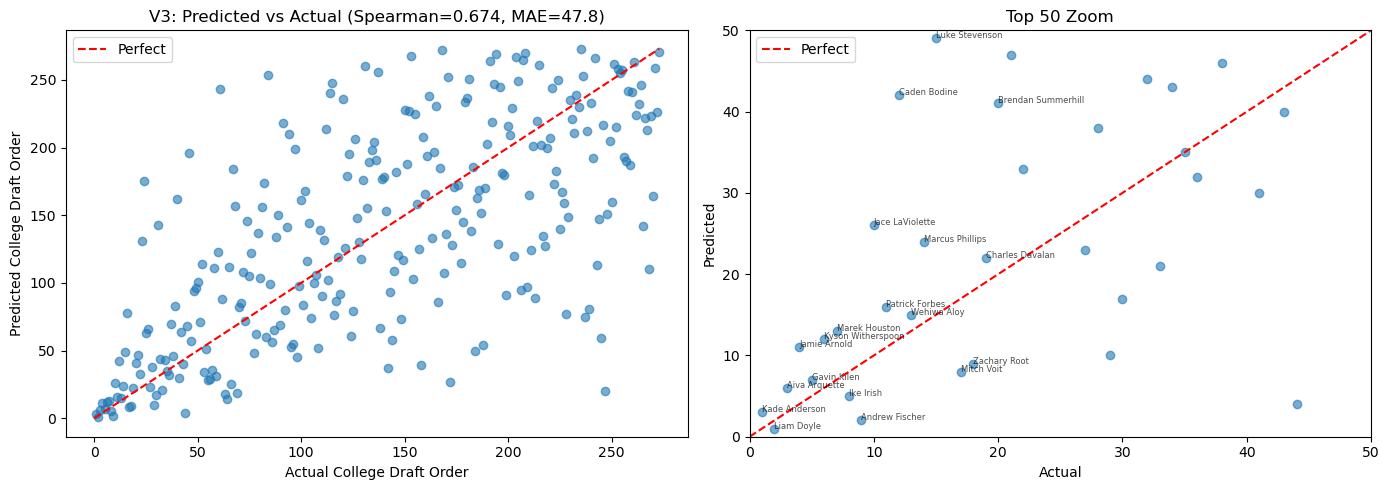

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
actual = results_rank_df['Actual_College_Order'].values
predicted = results_rank_df['Predicted_College_Order'].values
n_test = len(results_rank_df)

axes[0].scatter(actual, predicted, alpha=0.6)
axes[0].plot([0, n_test], [0, n_test], 'r--', label='Perfect')
axes[0].set_xlabel('Actual College Draft Order'); axes[0].set_ylabel('Predicted College Draft Order')
axes[0].set_title(f'V3: Predicted vs Actual (Spearman={final_result["spearman"]:.3f}, MAE={final_result["mae"]:.1f})')
axes[0].legend()

axes[1].scatter(actual, predicted, alpha=0.6)
for _, row in results_rank_df.head(20).iterrows():
    if row['Actual_College_Order'] <= 20 or row['Predicted_College_Order'] <= 20:
        axes[1].annotate(row['name'], (row['Actual_College_Order'], row['Predicted_College_Order']),
                         fontsize=6, alpha=0.7)
axes[1].plot([0, 50], [0, 50], 'r--', label='Perfect')
axes[1].set_xlim(0, 50); axes[1].set_ylim(0, 50)
axes[1].set_xlabel('Actual'); axes[1].set_ylabel('Predicted')
axes[1].set_title('Top 50 Zoom'); axes[1].legend()
plt.tight_layout(); plt.show()

## 11. Signing Bonus Prediction (Phase 2)

Excluded (data leakage): `api_pickValue`, `Pick`, `Round`, `College_Draft_Order`

In [21]:
bonus_df = draftedClean_df[draftedClean_df['api_signingBonus'].notna()].copy()
bonus_df['log_signingBonus'] = np.log1p(bonus_df['api_signingBonus'] * 1e6)

print(f"Signing bonus data: {len(bonus_df)} / {len(draftedClean_df)} ({len(bonus_df)/len(draftedClean_df)*100:.1f}%)")
print(f"Range: ${bonus_df['api_signingBonus'].min()*1e6:,.0f} - ${bonus_df['api_signingBonus'].max()*1e6:,.0f}")

bonus_features_pitch = [f for f in final_pitcher_features if f not in ['api_pickValue']]
bonus_features_bat = [f for f in final_batter_features if f not in ['api_pickValue']]

print("\nSigning Bonus Model - Temporal CV:")
bonus_results = []
for train_years, test_year in temporal_folds:
    train_b = bonus_df[bonus_df[year_col].isin(train_years)]
    test_b = bonus_df[bonus_df[year_col] == test_year]
    if len(test_b) == 0: continue

    bp = dict(n_estimators=500, learning_rate=0.03, max_depth=4, subsample=0.8,
              colsample_bytree=0.7, min_child_weight=5, reg_alpha=1.0, reg_lambda=5.0,
              random_state=42, early_stopping_rounds=30, eval_metric='mae')
    bp_no_es = {k: v for k, v in bp.items() if k not in ('early_stopping_rounds', 'eval_metric')}

    all_pred, all_actual = [], []
    for role_val, feats in [(0, bonus_features_pitch), (1, bonus_features_bat)]:
        tr = train_b[train_b['role'] == role_val]
        te = test_b[test_b['role'] == role_val]
        if len(tr) == 0 or len(te) == 0: continue
        m = xgb.XGBRegressor(**bp)
        m.fit(tr[feats], tr['log_signingBonus'],
              eval_set=[(te[feats], te['log_signingBonus'])], verbose=False)
        all_pred.extend(m.predict(te[feats]))
        all_actual.extend(te['log_signingBonus'].values)

    # Both players
    te_both = test_b[test_b['role'] == 2]
    if len(te_both) > 0:
        tr_p = train_b[train_b['role'] == 0]
        tr_bt = train_b[train_b['role'] == 1]
        if len(tr_p) > 0 and len(tr_bt) > 0:
            mp = xgb.XGBRegressor(**bp_no_es); mp.fit(tr_p[bonus_features_pitch], tr_p['log_signingBonus'], verbose=False)
            mb = xgb.XGBRegressor(**bp_no_es); mb.fit(tr_bt[bonus_features_bat], tr_bt['log_signingBonus'], verbose=False)
            all_pred.extend((mp.predict(te_both[bonus_features_pitch]) + mb.predict(te_both[bonus_features_bat])) / 2)
            all_actual.extend(te_both['log_signingBonus'].values)

    if not all_actual: continue
    pred_d = np.expm1(np.array(all_pred))
    actual_d = np.expm1(np.array(all_actual))
    mae_d = mean_absolute_error(actual_d, pred_d)
    r2 = r2_score(actual_d, pred_d)
    corr_b, _ = spearmanr(actual_d, pred_d)
    bonus_results.append({'mae': mae_d, 'r2': r2, 'spearman': corr_b, 'n': len(all_actual)})
    print(f"  {train_years} -> {test_year}: MAE=${mae_d:,.0f}, R2={r2:.3f}, Spearman={corr_b:.3f} (n={len(all_actual)})")

if bonus_results:
    print(f"\n  Avg MAE: ${np.mean([r['mae'] for r in bonus_results]):,.0f}")
    print(f"  Avg R2: {np.mean([r['r2'] for r in bonus_results]):.3f}")
    print(f"  Avg Spearman: {np.mean([r['spearman'] for r in bonus_results]):.3f}")

Signing bonus data: 1400 / 1433 (97.7%)
Range: $1,000 - $9,250,000

Signing Bonus Model - Temporal CV:


  [2021] -> 2022: MAE=$297,597, R2=0.152, Spearman=0.650 (n=286)


  [2021, 2022] -> 2023: MAE=$423,047, R2=0.075, Spearman=0.671 (n=290)


  [2021, 2022, 2023] -> 2024: MAE=$464,367, R2=0.408, Spearman=0.802 (n=266)


  [2021, 2022, 2023, 2024] -> 2025: MAE=$373,877, R2=0.423, Spearman=0.719 (n=272)

  Avg MAE: $389,722
  Avg R2: 0.264
  Avg Spearman: 0.710


In [22]:
# Train final bonus models
bonus_train = bonus_df[bonus_df[year_col] < 2025]
bonus_test = bonus_df[bonus_df[year_col] == 2025]

bp_final = dict(n_estimators=1000, learning_rate=0.03, max_depth=4, subsample=0.8,
                colsample_bytree=0.7, min_child_weight=5, reg_alpha=1.0, reg_lambda=5.0,
                random_state=42, early_stopping_rounds=50, eval_metric='mae')
bp_final_no_es = {k: v for k, v in bp_final.items() if k not in ('early_stopping_rounds', 'eval_metric')}

# Pitcher bonus
ptr = bonus_train[bonus_train['role'] == 0]
pte = bonus_test[bonus_test['role'] == 0]
if len(ptr) > 0 and len(pte) > 0:
    final_pitch_bonus = xgb.XGBRegressor(**bp_final)
    final_pitch_bonus.fit(ptr[bonus_features_pitch], ptr['log_signingBonus'],
                          eval_set=[(pte[bonus_features_pitch], pte['log_signingBonus'])], verbose=False)
elif len(ptr) > 0:
    final_pitch_bonus = xgb.XGBRegressor(**bp_final_no_es)
    final_pitch_bonus.fit(ptr[bonus_features_pitch], ptr['log_signingBonus'], verbose=False)

# Batter bonus
btr = bonus_train[bonus_train['role'] == 1]
bte = bonus_test[bonus_test['role'] == 1]
if len(btr) > 0 and len(bte) > 0:
    final_bat_bonus = xgb.XGBRegressor(**bp_final)
    final_bat_bonus.fit(btr[bonus_features_bat], btr['log_signingBonus'],
                        eval_set=[(bte[bonus_features_bat], bte['log_signingBonus'])], verbose=False)
elif len(btr) > 0:
    final_bat_bonus = xgb.XGBRegressor(**bp_final_no_es)
    final_bat_bonus.fit(btr[bonus_features_bat], btr['log_signingBonus'], verbose=False)

print("Final bonus models trained")

Final bonus models trained


## 12. Player Lookup by Name (Phase 3a)

In [23]:
lookup_df = draftedClean_df.copy()
train_medians = draftedClean_df[draftedClean_df[year_col] < 2025].median(numeric_only=True)

def lookup_player(name_query, year=None):
    candidates = lookup_df if year is None else lookup_df[lookup_df[year_col] == year]
    names = candidates['nameascii'].dropna().unique().tolist()
    matches = get_close_matches(name_query, names, n=5, cutoff=0.4)
    if not matches:
        print(f"No match found for '{name_query}'"); return None

    player = candidates[candidates['nameascii'] == matches[0]].sort_values(year_col, ascending=False).iloc[0]

    role_name = {0: 'Pitcher', 1: 'Batter', 2: 'Both'}.get(player['role'], '?')
    print(f"{'='*60}")
    print(f"Player: {player['nameascii']}  |  Year: {int(player[year_col])}  |  Role: {role_name}")
    print(f"{'='*60}")

    if not pd.isna(player.get('api_height')):
        ft, inch = int(player['api_height'] // 12), int(player['api_height'] % 12)
        print(f"Height: {ft}'{inch}\"  |  Weight: {int(player.get('api_weight', 0))} lbs")

    pos_rev = {1:'C', 2:'SS', 3:'2B', 4:'3B', 5:'CF', 6:'LF', 7:'RF', 8:'IF', 9:'1B', 10:'OF', 11:'DH', 12:'P', 13:'TWP'}
    if not pd.isna(player.get('api_primaryPos')):
        print(f"Position: {pos_rev.get(int(player['api_primaryPos']), '?')}")

    print(f"\n--- Key Stats ---")
    if player['role'] in [0, 2]:
        for s in ['era_pitch', 'fip_pitch', 'k/9_pitch', 'bb/9_pitch', 'whip_pitch', 'ip_pitch', 'so_pitch']:
            if not pd.isna(player.get(s)): print(f"  {s}: {player[s]:.2f}")
    if player['role'] in [1, 2]:
        for s in ['avg_bat', 'ops_bat', 'hr_bat', 'wrc+_bat', 'woba_bat', 'slg_bat']:
            if not pd.isna(player.get(s)):
                v = player[s]; print(f"  {s}: {v:.3f}" if isinstance(v, float) and v < 10 else f"  {s}: {v:.1f}")

    # Draft probability
    cls_row = player.reindex(all_classification_features)
    draft_prob = draft_classifier.predict_proba(pd.DataFrame([cls_row.values], columns=all_classification_features))[0][1]

    # College order
    if player['role'] == 0:
        log_pred = final_pitch_model.predict(pd.DataFrame([player.reindex(final_pitcher_features).values], columns=final_pitcher_features))[0]
        log_bonus = final_pitch_bonus.predict(pd.DataFrame([player.reindex(bonus_features_pitch).values], columns=bonus_features_pitch))[0]
    elif player['role'] == 1:
        log_pred = final_bat_model.predict(pd.DataFrame([player.reindex(final_batter_features).values], columns=final_batter_features))[0]
        log_bonus = final_bat_bonus.predict(pd.DataFrame([player.reindex(bonus_features_bat).values], columns=bonus_features_bat))[0]
    else:
        fp = pd.DataFrame([player.reindex(final_pitcher_features).values], columns=final_pitcher_features)
        fb = pd.DataFrame([player.reindex(final_batter_features).values], columns=final_batter_features)
        log_pred = (final_pitch_model.predict(fp)[0] + final_bat_model.predict(fb)[0]) / 2
        fbp = pd.DataFrame([player.reindex(bonus_features_pitch).values], columns=bonus_features_pitch)
        fbb = pd.DataFrame([player.reindex(bonus_features_bat).values], columns=bonus_features_bat)
        log_bonus = (final_pitch_bonus.predict(fbp)[0] + final_bat_bonus.predict(fbb)[0]) / 2

    print(f"\n--- Predictions ---")
    print(f"Draft Probability: {draft_prob*100:.1f}%")
    print(f"Predicted College Draft Order: ~{int(round(np.expm1(log_pred)))}")
    print(f"Predicted Signing Bonus: ${np.expm1(log_bonus):,.0f}")

    if not pd.isna(player.get('Pick')):
        print(f"\n--- Actual ---")
        print(f"Pick: {int(player['Pick'])} (Round {int(player.get('Round', 0))})")
        if not pd.isna(player.get('College_Draft_Order')): print(f"College Order: {int(player['College_Draft_Order'])}")
        if not pd.isna(player.get('api_signingBonus')): print(f"Signing Bonus: ${player['api_signingBonus']*1e6:,.0f}")

    if len(matches) > 1: print(f"\nOther matches: {matches[1:]}")
    return player

print("lookup_player() defined. Usage: lookup_player('Jace LaViolette')")

lookup_player() defined. Usage: lookup_player('Jace LaViolette')


In [24]:
lookup_player('Jace LaViolette')

Player: Jace LaViolette  |  Year: 2025  |  Role: Batter
Height: 6'6"  |  Weight: 230 lbs
Position: OF

--- Key Stats ---
  avg_bat: 0.258
  ops_bat: 1.003
  hr_bat: 18.0
  wrc+_bat: 119.7
  woba_bat: 0.435
  slg_bat: 0.576

--- Predictions ---
Draft Probability: 99.8%
Predicted College Draft Order: ~49
Predicted Signing Bonus: $573,989

--- Actual ---
Pick: 27 (Round 1)
College Order: 10
Signing Bonus: $4,000,000

Other matches: ['Jack Leiter', 'Jake Clemente', 'Garret Guillemette', 'Jake Miller']


age                                   21.0
nameascii                  Jace LaViolette
year                                  2025
w_pitch                                NaN
l_pitch                                NaN
                                ...       
api_pickValue                       3.3826
api_signingBonus                       4.0
bmi                              26.576266
College_Draft_Order                     10
log_College_Draft_Order           2.397895
Name: 630, Length: 143, dtype: object

In [25]:
lookup_player('Kade Anderson')

Player: Kade Anderson  |  Year: 2025  |  Role: Pitcher
Height: 6'2"  |  Weight: 179 lbs
Position: P

--- Key Stats ---
  era_pitch: 3.18
  fip_pitch: 3.42
  k/9_pitch: 13.61
  bb/9_pitch: 2.65
  whip_pitch: 1.06
  ip_pitch: 119.00
  so_pitch: 180.00

--- Predictions ---
Draft Probability: 98.1%
Predicted College Draft Order: ~11
Predicted Signing Bonus: $2,394,632

--- Actual ---
Pick: 3 (Round 1)
College Order: 1
Signing Bonus: $8,800,000

Other matches: ['Casey Anderson', 'Ethan Anderson', 'Kade Kern', 'Cade Vernon']


age                                 20.0
nameascii                  Kade Anderson
year                                2025
w_pitch                             12.0
l_pitch                              1.0
                               ...      
api_pickValue                     9.5044
api_signingBonus                     8.8
bmi                             22.97973
College_Draft_Order                    1
log_College_Draft_Order         0.693147
Name: 866, Length: 143, dtype: object

## 13. Custom Stats Input (Phase 3b)

In [26]:
PITCHER_TEMPLATE = {
    'age': 21, 'era_pitch': 3.50, 'fip_pitch': 3.40, 'ip_pitch': 90.0,
    'so_pitch': 100, 'bb_pitch': 25, 'h_pitch': 75, 'hr_pitch': 5,
    'g_pitch': 15, 'gs_pitch': 14, 'w_pitch': 8, 'l_pitch': 3,
    'k/9_pitch': 10.0, 'bb/9_pitch': 2.5, 'k/bb_pitch': 4.0, 'whip_pitch': 1.10,
    'k%_pitch': 0.28, 'bb%_pitch': 0.07, 'k-bb%_pitch': 0.21,
    'avg_pitch': 0.230, 'babip_pitch': 0.290, 'lob%_pitch': 0.72,
    'hr/9_pitch': 0.5, 'e-f_pitch': 0.5, 'sv_pitch': 0, 'tbf_pitch': 350,
    'r_pitch': 40, 'er_pitch': 35, 'hbp_pitch': 5, 'wp_pitch': 3, 'bk_pitch': 0, 'cg_pitch': 0, 'sho_pitch': 0,
}

BATTER_TEMPLATE = {
    'age': 21, 'avg_bat': 0.300, 'ops_bat': 0.900, 'hr_bat': 15,
    'wrc+_bat': 130, 'woba_bat': 0.400, 'slg_bat': 0.520, 'obp_bat': 0.400,
    'bb%_bat': 0.12, 'k%_bat': 0.15, 'iso_bat': 0.200,
    'g_bat': 55, 'ab_bat': 200, 'pa_bat': 240, 'h_bat': 60,
    '1b_bat': 35, '2b_bat': 15, '3b_bat': 2, 'r_bat': 40,
    'rbi_bat': 45, 'bb_bat': 30, 'so_bat': 35, 'hbp_bat': 5,
    'sf_bat': 3, 'sh_bat': 1, 'gdp_bat': 3, 'sb_bat': 10, 'cs_bat': 2,
    'spd_bat': 5.0, 'babip_bat': 0.330, 'wsb_bat': 1.0, 'wrc_bat': 40.0, 'wraa_bat': 15.0, 'bb/k_bat': 0.8,
}

def predict_from_stats(role, age, stats_dict, team_stats_dict=None):
    role_num = {'Pitcher': 0, 'Batter': 1, 'Both': 2}[role]
    row = pd.Series(dtype=float)
    row['age'] = age; row['role'] = role_num
    for k, v in stats_dict.items(): row[k] = v

    # Engineered features
    ip = row.get('ip_pitch', np.nan); pa = row.get('pa_bat', np.nan); ab = row.get('ab_bat', np.nan)
    row['so_per_ip'] = row.get('so_pitch', np.nan) / ip if not pd.isna(ip) and ip > 0 else np.nan
    row['bb_per_ip'] = row.get('bb_pitch', np.nan) / ip if not pd.isna(ip) and ip > 0 else np.nan
    row['hr_per_ip'] = row.get('hr_pitch', np.nan) / ip if not pd.isna(ip) and ip > 0 else np.nan
    row['hr_per_ab_bat'] = row.get('hr_bat', np.nan) / ab if not pd.isna(ab) and ab > 0 else np.nan
    row['k_per_pa'] = row.get('so_bat', np.nan) / pa if not pd.isna(pa) and pa > 0 else np.nan
    row['bb_per_pa'] = row.get('bb_bat', np.nan) / pa if not pd.isna(pa) and pa > 0 else np.nan
    row['h_per_ab_bat'] = row.get('h_bat', np.nan) / ab if not pd.isna(ab) and ab > 0 else np.nan
    row['age_x_wrc+'] = age * row.get('wrc+_bat', np.nan)
    crpi = row.get('conf_rpi_team', np.nan); ops = row.get('ops_bat', np.nan)
    row['conf_rpi_x_ops'] = crpi * ops if not pd.isna(crpi) and not pd.isna(ops) else np.nan
    fip = row.get('fip_pitch', np.nan); cr = row.get('conf_rank_team', np.nan)
    row['fip_x_conf_rank'] = fip * cr if not pd.isna(fip) and not pd.isna(cr) else np.nan

    # Team features from medians
    if team_stats_dict:
        for k, v in team_stats_dict.items(): row[k] = v
    else:
        for f in team_features:
            if f not in row or pd.isna(row.get(f)): row[f] = train_medians.get(f, np.nan)

    for f in ['api_batSide', 'api_pitchHand', 'api_primaryPos', 'api_weight', 'api_height', 'bmi']:
        if f not in row: row[f] = np.nan

    draft_prob = draft_classifier.predict_proba(
        pd.DataFrame([row.reindex(all_classification_features).values], columns=all_classification_features))[0][1]

    if role_num == 0:
        log_pred = final_pitch_model.predict(pd.DataFrame([row.reindex(final_pitcher_features).values], columns=final_pitcher_features))[0]
        log_bonus = final_pitch_bonus.predict(pd.DataFrame([row.reindex(bonus_features_pitch).values], columns=bonus_features_pitch))[0]
    elif role_num == 1:
        log_pred = final_bat_model.predict(pd.DataFrame([row.reindex(final_batter_features).values], columns=final_batter_features))[0]
        log_bonus = final_bat_bonus.predict(pd.DataFrame([row.reindex(bonus_features_bat).values], columns=bonus_features_bat))[0]
    else:
        rp = pd.DataFrame([row.reindex(final_pitcher_features).values], columns=final_pitcher_features)
        rb = pd.DataFrame([row.reindex(final_batter_features).values], columns=final_batter_features)
        log_pred = (final_pitch_model.predict(rp)[0] + final_bat_model.predict(rb)[0]) / 2
        bp = pd.DataFrame([row.reindex(bonus_features_pitch).values], columns=bonus_features_pitch)
        bb = pd.DataFrame([row.reindex(bonus_features_bat).values], columns=bonus_features_bat)
        log_bonus = (final_pitch_bonus.predict(bp)[0] + final_bat_bonus.predict(bb)[0]) / 2

    print(f"{'='*50}")
    print(f"Custom {role} Prediction (age {age})")
    print(f"{'='*50}")
    print(f"Draft Probability: {draft_prob*100:.1f}%")
    print(f"Predicted College Draft Order: ~{int(round(np.expm1(log_pred)))}")
    print(f"Predicted Signing Bonus: ${np.expm1(log_bonus):,.0f}")
    return {'draft_prob': draft_prob, 'pred_order': np.expm1(log_pred), 'pred_bonus': np.expm1(log_bonus)}

print("predict_from_stats() defined.")
print("Templates: PITCHER_TEMPLATE, BATTER_TEMPLATE")

predict_from_stats() defined.
Templates: PITCHER_TEMPLATE, BATTER_TEMPLATE


In [27]:
predict_from_stats('Pitcher', 21, {
    'era_pitch': 2.50, 'fip_pitch': 2.80, 'so_pitch': 120, 'ip_pitch': 95.0,
    'bb_pitch': 20, 'k/9_pitch': 11.4, 'bb/9_pitch': 1.9, 'whip_pitch': 0.95,
    'k%_pitch': 0.32, 'bb%_pitch': 0.06, 'k-bb%_pitch': 0.26,
    'g_pitch': 16, 'gs_pitch': 16, 'w_pitch': 10, 'l_pitch': 2,
})

Custom Pitcher Prediction (age 21)
Draft Probability: 99.1%
Predicted College Draft Order: ~50
Predicted Signing Bonus: $873,617


{'draft_prob': 0.99142915, 'pred_order': 49.72428, 'pred_bonus': 873617.4}

In [28]:
predict_from_stats('Batter', 21, {
    'avg_bat': 0.330, 'ops_bat': 1.050, 'hr_bat': 22, 'wrc+_bat': 170,
    'woba_bat': 0.440, 'slg_bat': 0.620, 'obp_bat': 0.430,
    'bb%_bat': 0.14, 'k%_bat': 0.12, 'iso_bat': 0.280,
    'g_bat': 58, 'ab_bat': 210, 'pa_bat': 255, 'h_bat': 69,
    'r_bat': 55, 'rbi_bat': 60, 'sb_bat': 15,
})

Custom Batter Prediction (age 21)
Draft Probability: 97.9%
Predicted College Draft Order: ~11
Predicted Signing Bonus: $1,276,886


{'draft_prob': 0.97942126, 'pred_order': 10.643002, 'pred_bonus': 1276885.9}

## 14. Algorithm Comparison (Phase 4)

XGBoost vs LightGBM vs HistGradientBoosting on same temporal CV splits.

In [29]:
from sklearn.ensemble import HistGradientBoostingRegressor
try:
    import lightgbm as lgb; HAS_LGBM = True
except ImportError:
    HAS_LGBM = False; print("LightGBM not installed, skipping.")

def evaluate_model_temporal(model_class, model_params):
    fold_results = []
    for train_years, test_year in temporal_folds:
        train_data = draftedClean_df[draftedClean_df[year_col].isin(train_years)]
        test_data = draftedClean_df[draftedClean_df[year_col] == test_year]

        all_preds, all_actual = [], []
        for role_val, feats in [(0, final_pitcher_features), (1, final_batter_features)]:
            tr = train_data[train_data['role'] == role_val]
            te = test_data[test_data['role'] == role_val]
            if len(tr) == 0 or len(te) == 0: continue
            m = model_class(**model_params)
            m.fit(tr[feats], tr['log_College_Draft_Order'])
            all_preds.extend(m.predict(te[feats]))
            all_actual.extend(te['log_College_Draft_Order'].values)

        # Both
        both_te = test_data[test_data['role'] == 2]
        if len(both_te) > 0:
            p_tr = train_data[train_data['role'] == 0]
            b_tr = train_data[train_data['role'] == 1]
            if len(p_tr) > 0 and len(b_tr) > 0:
                mp = model_class(**model_params); mp.fit(p_tr[final_pitcher_features], p_tr['log_College_Draft_Order'])
                mb = model_class(**model_params); mb.fit(b_tr[final_batter_features], b_tr['log_College_Draft_Order'])
                all_preds.extend((mp.predict(both_te[final_pitcher_features]) + mb.predict(both_te[final_batter_features])) / 2)
                all_actual.extend(both_te['log_College_Draft_Order'].values)

        if not all_preds: continue
        pr = pd.Series(np.expm1(np.array(all_preds))).rank(method='min').astype(int).values
        ar = pd.Series(np.expm1(np.array(all_actual))).rank(method='min').astype(int).values
        corr, _ = spearmanr(ar, pr)
        fold_results.append({'spearman': corr, 'mae': mean_absolute_error(ar, pr)})
    return np.mean([r['spearman'] for r in fold_results]), np.mean([r['mae'] for r in fold_results])

xgb_sp = np.mean([r['spearman'] for r in final_results])
xgb_mae = np.mean([r['mae'] for r in final_results])

hist_sp, hist_mae = evaluate_model_temporal(HistGradientBoostingRegressor,
    dict(max_iter=500, learning_rate=0.03, max_depth=4, min_samples_leaf=5, random_state=42))

print("\n" + "="*70)
print("Algorithm Comparison (Temporal CV, Pitcher/Batter Split, Log Target)")
print("="*70)
print(f"{'Algorithm':<35} {'Avg Spearman':>15} {'Avg MAE':>10}")
print("-"*65)
print(f"{'XGBoost (V3 final)':<35} {xgb_sp:>15.3f} {xgb_mae:>10.1f}")

if HAS_LGBM:
    lgb_sp, lgb_mae = evaluate_model_temporal(lgb.LGBMRegressor,
        dict(n_estimators=500, learning_rate=0.03, max_depth=4, min_child_weight=5,
             colsample_bytree=0.7, subsample=0.8, reg_alpha=1.0, reg_lambda=5.0, random_state=42, verbose=-1))
    print(f"{'LightGBM':<35} {lgb_sp:>15.3f} {lgb_mae:>10.1f}")

print(f"{'HistGradientBoosting (sklearn)':<35} {hist_sp:>15.3f} {hist_mae:>10.1f}")

print("\nXGBoost is a solid choice. Biggest gains come from data/feature improvements,")
print("not algorithm swaps.")

LightGBM not installed, skipping.



Algorithm Comparison (Temporal CV, Pitcher/Batter Split, Log Target)
Algorithm                              Avg Spearman    Avg MAE
-----------------------------------------------------------------
XGBoost (V3 final)                            0.607       55.2
HistGradientBoosting (sklearn)                0.584       56.8

XGBoost is a solid choice. Biggest gains come from data/feature improvements,
not algorithm swaps.


## Summary

### V2 -> V3 Improvements
| Metric | V2 | V3 |
|--------|-----|-----|
| Approach | Single model, all features | Pitcher/batter split models |
| Target | Raw College_Draft_Order | log1p(College_Draft_Order) |
| Validation | Single train/test | Temporal cross-validation |
| Features | 118 raw features | Engineered + selected features |
| Hyperparameters | Manual | Grid search tuned |

### New Capabilities
- **Signing bonus prediction** from player stats
- **Player lookup** by name with fuzzy matching
- **Custom stat input** for hypothetical players
- **Algorithm comparison** across XGBoost, LightGBM, HistGradientBoosting